# part 1:

In [13]:
!pip install numpy pandas scikit-learn matplotlib xgboost

# part:2 

In [14]:
!pip install pandas numpy scikit-learn matplotlib joblib xgboost

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

In [16]:
df = pd.read_csv("Aquifer_Petrignano.csv")
df.head()

,Date,Rainfall_Bastia_Umbra,Depth_to_Groundwater_P24,Depth_to_Groundwater_P25,Temperature_Bastia_Umbra,Temperature_Petrignano,Volume_C10_Petrignano,Hydrometry_Fiume_Chiascio_Petrignano
0,14/03/2006,NaN,-22.48,-22.18,NaN,NaN,NaN,NaN
1,15/03/2006,NaN,-22.38,-22.14,NaN,NaN,NaN,NaN
2,16/03/2006,NaN,-22.25,-22.04,NaN,NaN,NaN,NaN
3,17/03/2006,NaN,-22.38,-22.04,NaN,NaN,NaN,NaN
4,18/03/2006,NaN,-22.60,-22.04,NaN,NaN,NaN,NaN


In [22]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df = df.sort_values("Date").reset_index(drop=True)

print(df.shape)
print(df.isnull().sum())

(5223, 12)
Date                                       0
Rainfall_Bastia_Umbra                   1024
Depth_to_Groundwater_P24                  55
Depth_to_Groundwater_P25                  39
Temperature_Bastia_Umbra                1024
Temperature_Petrignano                  1024
Volume_C10_Petrignano                    198
Hydrometry_Fiume_Chiascio_Petrignano    1024
year                                       0
month                                      0
day                                        0
dayofyear                                  0
dtype: int64


# Create time-based features

In [23]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["dayofyear"] = df["Date"].dt.dayofyear

# Select target and features

In [24]:
target = "Depth_to_Groundwater_P24"

features = [
    "Rainfall_Bastia_Umbra",
    "Depth_to_Groundwater_P25",
    "Temperature_Bastia_Umbra",
    "Temperature_Petrignano",
    "Volume_C10_Petrignano",
    "Hydrometry_Fiume_Chiascio_Petrignano",
    "year",
    "month",
    "day",
    "dayofyear"
]

# keep only needed columns first
model_df = df[features + [target]].copy()

# drop rows where target is missing
model_df = model_df.dropna(subset=[target])

X = model_df[features]
y = model_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Missing values in y:", y.isna().sum())

X shape: (5168, 10)
y shape: (5168,)
Missing values in y: 0


# Train/test split for time series

In [25]:
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (4134, 10) (4134,)
Test shape: (1034, 10) (1034,)


# Baseline model

In [27]:
baseline_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

baseline_pipeline.fit(X_train, y_train)
y_pred_baseline = baseline_pipeline.predict(X_test)

# TimeSeriesSplit

In [28]:
tscv = TimeSeriesSplit(n_splits=5)
tscv

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

# Random Forest with GridSearchCV

In [29]:
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV score:", rf_grid.best_score_)

Best RF params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best RF CV score: 0.027345177392360042


# AdaBoost with GridSearchCV

In [30]:
ada_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", AdaBoostRegressor(random_state=42))
])

ada_params = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.1, 1.0]
}

ada_grid = GridSearchCV(
    estimator=ada_pipeline,
    param_grid=ada_params,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

ada_grid.fit(X_train, y_train)

best_ada = ada_grid.best_estimator_
y_pred_ada = best_ada.predict(X_test)

print("Best Ada params:", ada_grid.best_params_)
print("Best Ada CV score:", ada_grid.best_score_)

Best Ada params: {'model__learning_rate': 1.0, 'model__n_estimators': 200}
Best Ada CV score: 0.1371144060273605


# XGBoost with GridSearchCV

In [31]:
xgb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        verbosity=0
    ))
])

xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_params,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("Best XGB params:", xgb_grid.best_params_)
print("Best XGB CV score:", xgb_grid.best_score_)

Best XGB params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
Best XGB CV score: -0.044516381311714245


# Evaluation function

In [33]:
def evaluate_model(name, y_true, y_pred, n_features):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    n = len(y_true)
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

    return {
        "Model": name,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adjusted_r2
    }

# Results table

In [34]:
results = [
    evaluate_model("Baseline Linear Regression", y_test, y_pred_baseline, X_test.shape[1]),
    evaluate_model("Random Forest", y_test, y_pred_rf, X_test.shape[1]),
    evaluate_model("AdaBoost", y_test, y_pred_ada, X_test.shape[1]),
    evaluate_model("XGBoost", y_test, y_pred_xgb, X_test.shape[1]),
]

results_df = pd.DataFrame(results)
results_df.sort_values(by="R2", ascending=False)

,Model,MSE,MAE,RMSE,R2,Adjusted_R2
0,Baseline Linear Regression,0.027985,0.119233,0.167286,0.974159,0.973907
1,Random Forest,0.161768,0.269445,0.402204,0.850626,0.849165
2,AdaBoost,0.487008,0.577385,0.697859,0.550305,0.545909
3,XGBoost,1.220105,0.539979,1.104584,-0.126625,-0.137638


# R² comparison chart

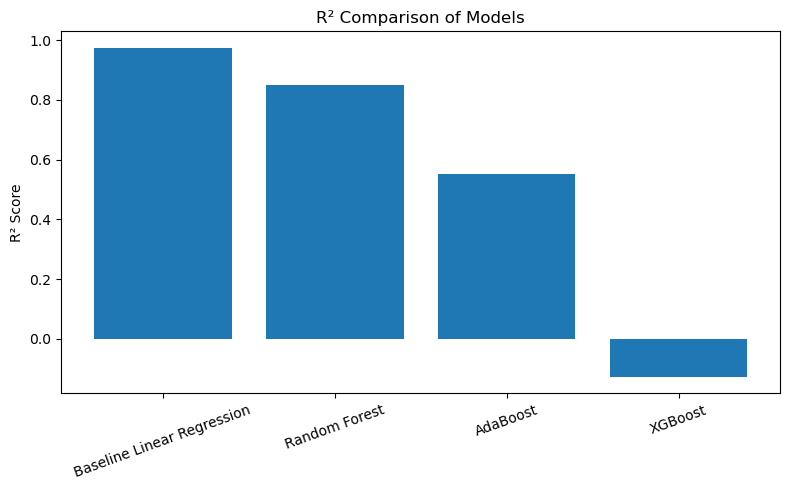

In [35]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["R2"])
plt.title("R² Comparison of Models")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# RMSE comparison chart

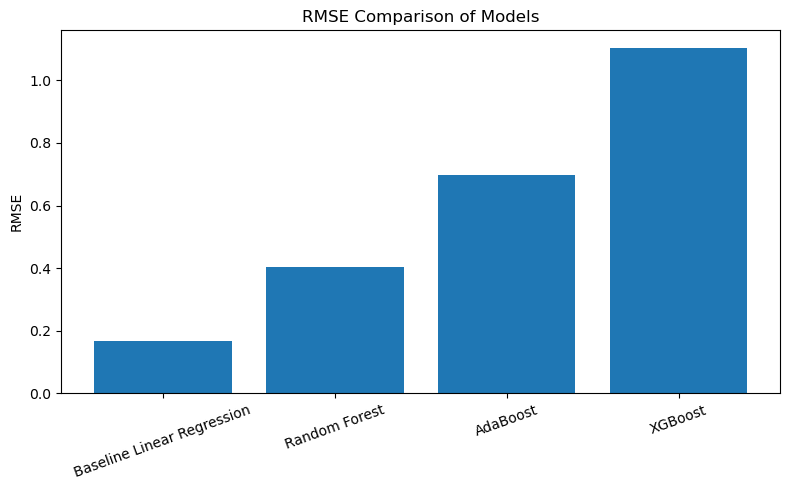

In [36]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("RMSE Comparison of Models")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Actual vs predicted for best Random Forest

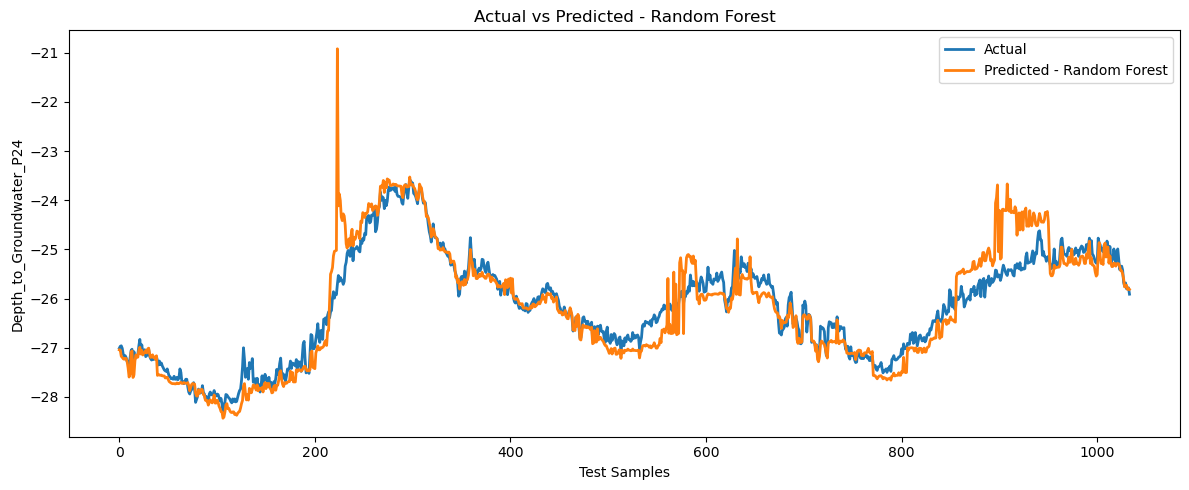

In [37]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(y_pred_rf, label="Predicted - Random Forest", linewidth=2)
plt.title("Actual vs Predicted - Random Forest")
plt.xlabel("Test Samples")
plt.ylabel("Depth_to_Groundwater_P24")
plt.legend()
plt.tight_layout()
plt.show()

# Error distribution for Random Forest

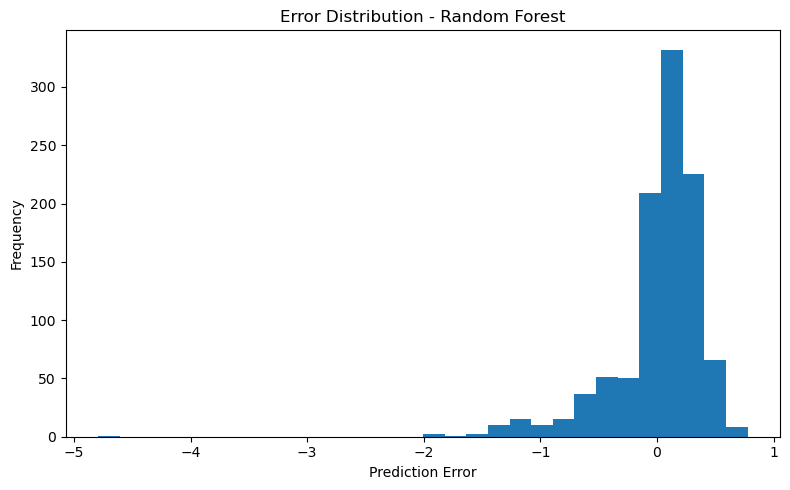

In [38]:
rf_errors = y_test.values - y_pred_rf

plt.figure(figsize=(8, 5))
plt.hist(rf_errors, bins=30)
plt.title("Error Distribution - Random Forest")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Fold-by-fold validation scores

In [41]:
rf_fold_scores = []
ada_fold_scores = []
xgb_fold_scores = []

for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    best_rf.fit(X_tr, y_tr)
    rf_pred = best_rf.predict(X_val)
    rf_fold_scores.append(r2_score(y_val, rf_pred))

    best_ada.fit(X_tr, y_tr)
    ada_pred = best_ada.predict(X_val)
    ada_fold_scores.append(r2_score(y_val, ada_pred))

    best_xgb.fit(X_tr, y_tr)
    xgb_pred = best_xgb.predict(X_val)
    xgb_fold_scores.append(r2_score(y_val, xgb_pred))

print("RF fold R2:", rf_fold_scores)
print("Ada fold R2:", ada_fold_scores)
print("XGB fold R2:", xgb_fold_scores)

C:\Users\mdjon\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Rainfall_Bastia_Umbra' 'Temperature_Bastia_Umbra'
 'Temperature_Petrignano' 'Hydrometry_Fiume_Chiascio_Petrignano']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\mdjon\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Rainfall_Bastia_Umbra' 'Temperature_Bastia_Umbra'
 'Temperature_Petrignano' 'Hydrometry_Fiume_Chiascio_Petrignano']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\mdjon\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Rainfall_Bastia_Umbra' 'Temperature_Bastia_Umbra'
 'Temperature_Petrignano' 'Hydrometry_Fiume_Chiascio_Petrignano']. At least one non-missing value is needed for imputati

RF fold R2: [0.7327710516798923, 0.9070923119415201, 0.9825807642014374, -0.7569009373766376, -1.728817303484412]
Ada fold R2: [0.6054331550251486, 0.7832777610630345, 0.9757045642804855, -1.5689814396536947, -0.10986201057817135]
XGB fold R2: [0.6975180736828505, 0.9076834665688428, 0.9859079913935257, -1.0984237055048829, -1.7152677326989072]


In [40]:
missing_percent = model_df.isnull().mean() * 100
missing_percent.sort_values()

year                                     0.000000
month                                    0.000000
day                                      0.000000
dayofyear                                0.000000
Depth_to_Groundwater_P24                 0.000000
Depth_to_Groundwater_P25                 0.212848
Volume_C10_Petrignano                    3.811920
Rainfall_Bastia_Umbra                   19.504644
Temperature_Bastia_Umbra                19.504644
Temperature_Petrignano                  19.504644
Hydrometry_Fiume_Chiascio_Petrignano    19.504644
dtype: float64

# Fold comparison plot

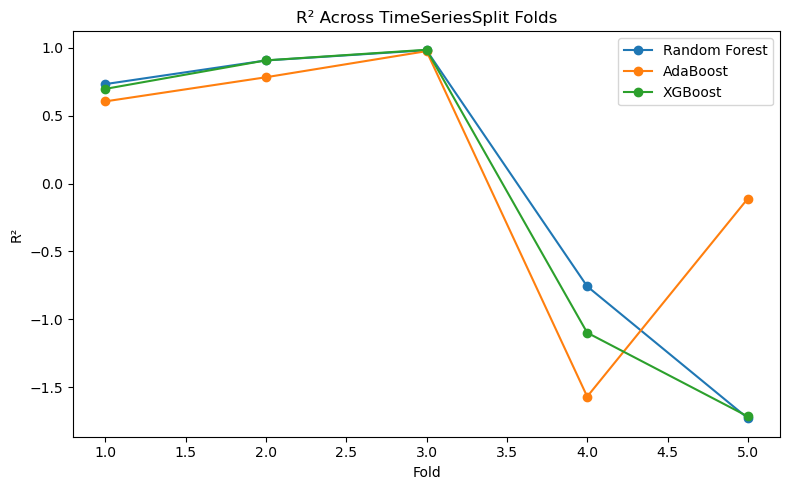

In [42]:
fold_numbers = list(range(1, len(rf_fold_scores) + 1))

plt.figure(figsize=(8, 5))
plt.plot(fold_numbers, rf_fold_scores, marker="o", label="Random Forest")
plt.plot(fold_numbers, ada_fold_scores, marker="o", label="AdaBoost")
plt.plot(fold_numbers, xgb_fold_scores, marker="o", label="XGBoost")
plt.title("R² Across TimeSeriesSplit Folds")
plt.xlabel("Fold")
plt.ylabel("R²")
plt.legend()
plt.tight_layout()
plt.show()

# Part 3: Incorporating Advanced Scikit-Learn Techniques

In [ ]:
# Pipeline with polynomial features

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, RobustScaler

poly_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

poly_pipeline.fit(X_train, y_train)
y_pred_poly = poly_pipeline.predict(X_test)

poly_result = evaluate_model("Polynomial Linear Regression", y_test, y_pred_poly, X_test.shape[1])
pd.DataFrame([poly_result])

,Model,MSE,MAE,RMSE,R2,Adjusted_R2
0,Polynomial Linear Regression,0.16152,0.354336,0.401896,0.850855,0.849397


In [ ]:
# RobustScaler pipeline

In [44]:
robust_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("model", LinearRegression())
])

robust_pipeline.fit(X_train, y_train)
y_pred_robust = robust_pipeline.predict(X_test)

robust_result = evaluate_model("RobustScaler + Linear Regression", y_test, y_pred_robust, X_test.shape[1])
pd.DataFrame([robust_result])

,Model,MSE,MAE,RMSE,R2,Adjusted_R2
0,RobustScaler + Linear Regression,0.027985,0.119233,0.167286,0.974159,0.973907


In [ ]:
# Compare advanced methods with previous results

In [45]:
advanced_results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([poly_result, robust_result])
    ],
    ignore_index=True
)

advanced_results_df.sort_values(by="R2", ascending=False)

,Model,MSE,MAE,RMSE,R2,Adjusted_R2
0,Baseline Linear Regression,0.027985,0.119233,0.167286,0.974159,0.973907
5,RobustScaler + Linear Regression,0.027985,0.119233,0.167286,0.974159,0.973907
4,Polynomial Linear Regression,0.161520,0.354336,0.401896,0.850855,0.849397
1,Random Forest,0.161768,0.269445,0.402204,0.850626,0.849165
2,AdaBoost,0.487008,0.577385,0.697859,0.550305,0.545909
3,XGBoost,1.220105,0.539979,1.104584,-0.126625,-0.137638


In [ ]:
# Plot advanced comparison

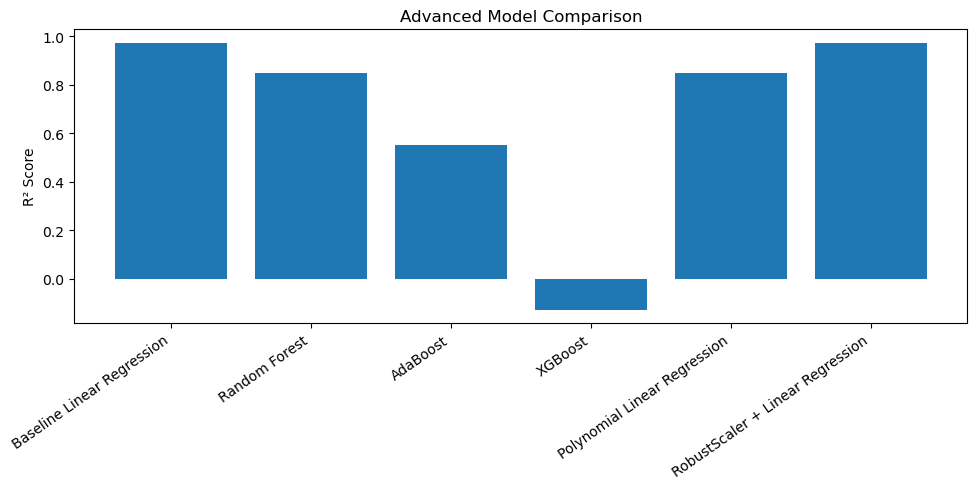

In [46]:
plt.figure(figsize=(10, 5))
plt.bar(advanced_results_df["Model"], advanced_results_df["R2"])
plt.title("Advanced Model Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [47]:
final_model = best_rf
joblib.dump(final_model, "best_rf_pipeline.pkl")
print("Model saved successfully.")

Model saved successfully.


In [48]:
loaded_model = joblib.load("best_rf_pipeline.pkl")
print("Model loaded successfully.")

Model loaded successfully.


In [49]:
loaded_predictions = loaded_model.predict(X_test)

same_predictions = np.allclose(y_pred_rf, loaded_predictions)
print("Predictions identical after loading:", same_predictions)

Predictions identical after loading: False


In [ ]:
# Version info for reproducibility

In [50]:
import sklearn
import sys
import xgboost

print("Python version:", sys.version)
print("scikit-learn version:", sklearn.__version__)
print("xgboost version:", xgboost.__version__)

Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
scikit-learn version: 1.7.2
xgboost version: 3.2.0
